
# Working with XES Event Logs in Python

**This notebook is part of the Process Intelligence in Action (2AMI30) course**

This notebook is a hands-on introduction to the **XES (.xes) event log format**, which is widely used in **process mining**.  
You are expected to be comfortable with Python, pandas, and Jupyter notebooks.

This notebook will cover:
- Understanding the structure of an XES file (log → trace → event)
- Loading and inspecting XES files in Python
- Converting XES logs to pandas DataFrames
- Performing basic exploratory analysis on event logs

We will use the `pm4py` library, the de‑facto standard for process mining in Python.



## 1. Understanding the structure of an XES file

The **eXtensible Event Stream (XES)** format is an XML-based standard for event logs.

Conceptually, an XES log has three nested levels:

1. **Log** – the whole dataset
2. **Trace** – one process instance
3. **Event** – one step in the process

Each level can have **attributes**:
- Events typically have: `concept:name`, `time:timestamp`, `org:resource`
- Traces often have: `case_id`, `customer`, `variant`

Think of a trace as a sequence of time-ordered events describing *what happened* for a single case.



## 2. Required libraries

We use **pm4py** for reading and analyzing XES logs.

If pm4py is not installed, run the following (once):
```bash
pip install pm4py
```


In [41]:

import pm4py
import pandas as pd

from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.objects.conversion.log import converter as log_converter



## 3. Loading an XES file

Place your `.xes` file in the same directory as this notebook, or update the path below.


In [ ]:
from pathlib import Path

# Optional: update this to the folder containing your .xes files
# If the folder does not exist the notebook directory will be used.
xes_dir = Path(r"D:\TUE Study Material\Q4\Process Intelligence in Action\Assignment\Process-Intelligence-in-Action\Gauri\")
if not xes_dir.exists():
    xes_dir = Path('.')  # fallback to notebook directory

file_names = {
    'cashier': 'Supermarket_Cashier.xes',
    'clerk': 'Supermarket_Clerk.xes',
    'counter': 'Supermarket_Counter.xes',
    'customer': 'Supermarket_Customer.xes',
    'manager': 'Supermarket_Manager.xes',
}

logs = {}
for key, fname in file_names.items():
    path = xes_dir / fname
    if not path.exists():
        print(f"Warning: {path} not found. Skipping {key}.")
        continue
    try:
        logs[key] = xes_importer.apply(str(path))
        print(f"Loaded {fname}  {len(logs[key])} traces")
    except Exception as e:
        print(f"Error loading {fname}: {e}")

# Convenience variables for later cells
log = logs.get('cashier')
log_cashier = logs.get('cashier')
log_clerk = logs.get('clerk')
log_counter = logs.get('counter')
log_customer = logs.get('customer')
log_manager = logs.get('manager')

if log is not None:
    print(type(log))
    print(f"Number of traces: {len(log)}")
else:
    print("No log loaded for 'cashier' (log is None).")

parsing log, completed traces ::   0%|          | 0/37 [00:00<?, ?it/s]

<class 'pm4py.objects.log.obj.EventLog'>
Number of traces: 37



## 4. Inspecting traces and events

An imported XES log behaves like a **list of traces**.
Each trace behaves like a **list of events**.


In [43]:

# Inspect the first trace
first_trace = log[0]

print(type(first_trace))
print(f"Number of events in first trace: {len(first_trace)}")
print("Trace attributes:")
print(first_trace.attributes)


<class 'pm4py.objects.log.obj.Trace'>
Number of events in first trace: 116
Trace attributes:
{'concept:name': '10'}


In [44]:
log[0]

{'attributes': {'concept:name': '10'}, 'events': [{'hr': 16.0, 'lifecycle:transition': 'complete', 'concept:name': 'Start Shift', 'd': 4.0, 'day': 0.0, 'time:timestamp': datetime.datetime(2026, 1, 26, 16, 0, tzinfo=datetime.timezone.utc), 'col': nan, 'q': nan, 'iMI': nan, 'mC': nan, 'mI': nan, 'iMC': nan, 'cid': nan, 'cnt': nan, 'x': nan, 'pc': nan}, '..', {'hr': nan, 'lifecycle:transition': 'complete', 'concept:name': 'End shift', 'd': nan, 'day': nan, 'time:timestamp': datetime.datetime(2026, 3, 6, 20, 0, tzinfo=datetime.timezone.utc), 'col': nan, 'q': nan, 'iMI': nan, 'mC': nan, 'mI': nan, 'iMC': nan, 'cid': nan, 'cnt': nan, 'x': 8.0, 'pc': 0.0}]}

In [45]:

# Inspect the first event of the first trace
first_event = first_trace[0]

print(type(first_event))
print(first_event)


<class 'pm4py.objects.log.obj.Event'>
{'hr': 16.0, 'lifecycle:transition': 'complete', 'concept:name': 'Start Shift', 'd': 4.0, 'day': 0.0, 'time:timestamp': datetime.datetime(2026, 1, 26, 16, 0, tzinfo=datetime.timezone.utc), 'col': nan, 'q': nan, 'iMI': nan, 'mC': nan, 'mI': nan, 'iMC': nan, 'cid': nan, 'cnt': nan, 'x': nan, 'pc': nan}



## 5. Common event attributes

Typical event attributes you should always look for:
- `concept:name` – the activity name
- `time:timestamp` – when the event occurred
- `org:resource` – who executed it (if available)

Not all logs contain all attributes.


In [46]:

# Collect all event attribute keys in the log
attribute_keys = set()

for trace in log:
    for event in trace:
        attribute_keys.update(event.keys())

attribute_keys


{'cid',
 'cnt',
 'col',
 'concept:name',
 'd',
 'day',
 'hr',
 'iMC',
 'iMI',
 'lifecycle:transition',
 'mC',
 'mI',
 'pc',
 'q',
 'time:timestamp',
 'x'}


## 6. Converting an XES log to a pandas DataFrame

For data science workflows, it is often convenient to work with a **tabular representation**.

pm4py provides a built-in conversion.


In [47]:

log_df = log_converter.apply(log, variant=log_converter.Variants.TO_DATA_FRAME)

log_df.head(10)


,hr,lifecycle:transition,concept:name,d,day,time:timestamp,col,q,iMI,mC,mI,iMC,cid,cnt,x,pc,case:concept:name
0,16.0,complete,Start Shift,4.0,0.0,2026-01-26 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
1,NaN,complete,Open counter,4.0,NaN,2026-01-26 16:00:00+00:00,"[(0,0,0,true),(1,1,19,true),(2,0,0,true),(3,0,...","[7,8,9,10,11,12,13,14,15,16,17]",0.0,0.0,0.0,0.0,6.0,NaN,NaN,NaN,10
2,NaN,complete,Close counter,4.0,NaN,2026-01-26 20:00:00+00:00,"[(0,2,92,true),(1,0,0,false),(2,1,5,true),(3,2...","[4,5,1,12,13,14,15,16,17]",7.0,0.0,0.0,9.0,6.0,17.0,40.0,NaN,10
3,NaN,complete,End shift,NaN,NaN,2026-01-26 20:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,10
4,16.0,complete,Start Shift,4.0,1.0,2026-01-27 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
5,NaN,complete,Open counter,4.0,NaN,2026-01-27 16:00:00+00:00,"[(0,2,29,true),(1,1,52,true),(2,1,27,true),(3,...","[9,10,11,12,13,14,15,16,17]",4.0,0.0,0.0,4.0,8.0,NaN,NaN,NaN,10
6,NaN,complete,Close counter,4.0,NaN,2026-01-27 20:00:00+00:00,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[15,16,17,0,5,1,4,2,3,9,6]",10.0,1.0,0.0,8.0,8.0,21.0,40.0,NaN,10
7,NaN,complete,End shift,NaN,NaN,2026-01-27 20:01:49.936000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,0.0,10
8,16.0,complete,Start Shift,4.0,2.0,2026-01-28 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
9,NaN,complete,Open counter,4.0,NaN,2026-01-28 16:00:00+00:00,"[(0,1,60,true),(1,2,70,true),(2,0,0,true),(3,0...","[9,10,11,12,13,14,15,16,17]",2.0,0.0,0.0,2.0,8.0,NaN,NaN,NaN,10



### Interpreting the DataFrame

Typical columns:
- `case:concept:name` → case ID
- `concept:name` → activity
- `time:timestamp` → event time

Each row corresponds to **one event**.
Multiple rows with the same case ID form a trace.



## 7. Basic exploratory analysis


In [9]:

# Number of events
len(log_df)


2928

In [10]:

# Number of unique cases
log_df['case:concept:name'].nunique()


37

In [11]:

# Most frequent activities
log_df['concept:name'].value_counts().head(10)


concept:name
Start Shift      732
Open counter     732
Close counter    732
End shift        732
Name: count, dtype: int64

In [12]:

# Trace length distribution
trace_lengths = log_df.groupby('case:concept:name').size()
trace_lengths.describe()


count     37.000000
mean      79.135135
std       72.130346
min       20.000000
25%       28.000000
50%       40.000000
75%      112.000000
max      240.000000
dtype: float64


## 8. Event ordering and timestamps

Event order **must always be derived from timestamps**, not row order.


In [48]:

# Ensure correct ordering
log_df_sorted = log_df.sort_values(
    ['case:concept:name', 'time:timestamp']
)

log_df_sorted.head(10)


,hr,lifecycle:transition,concept:name,d,day,time:timestamp,col,q,iMI,mC,mI,iMC,cid,cnt,x,pc,case:concept:name
0,16.0,complete,Start Shift,4.0,0.0,2026-01-26 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
1,NaN,complete,Open counter,4.0,NaN,2026-01-26 16:00:00+00:00,"[(0,0,0,true),(1,1,19,true),(2,0,0,true),(3,0,...","[7,8,9,10,11,12,13,14,15,16,17]",0.0,0.0,0.0,0.0,6.0,NaN,NaN,NaN,10
2,NaN,complete,Close counter,4.0,NaN,2026-01-26 20:00:00+00:00,"[(0,2,92,true),(1,0,0,false),(2,1,5,true),(3,2...","[4,5,1,12,13,14,15,16,17]",7.0,0.0,0.0,9.0,6.0,17.0,40.0,NaN,10
3,NaN,complete,End shift,NaN,NaN,2026-01-26 20:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,10
4,16.0,complete,Start Shift,4.0,1.0,2026-01-27 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
5,NaN,complete,Open counter,4.0,NaN,2026-01-27 16:00:00+00:00,"[(0,2,29,true),(1,1,52,true),(2,1,27,true),(3,...","[9,10,11,12,13,14,15,16,17]",4.0,0.0,0.0,4.0,8.0,NaN,NaN,NaN,10
6,NaN,complete,Close counter,4.0,NaN,2026-01-27 20:00:00+00:00,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[15,16,17,0,5,1,4,2,3,9,6]",10.0,1.0,0.0,8.0,8.0,21.0,40.0,NaN,10
7,NaN,complete,End shift,NaN,NaN,2026-01-27 20:01:49.936000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,0.0,10
8,16.0,complete,Start Shift,4.0,2.0,2026-01-28 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
9,NaN,complete,Open counter,4.0,NaN,2026-01-28 16:00:00+00:00,"[(0,1,60,true),(1,2,70,true),(2,0,0,true),(3,0...","[9,10,11,12,13,14,15,16,17]",2.0,0.0,0.0,2.0,8.0,NaN,NaN,NaN,10


## 9. Computing case duration

Case duration is the time between the first and last event of a case (trace).
This is one of the most basic but informative performance indicators.

In [23]:
# Compute case start and end times
case_times = (
    log_df_sorted
    .groupby('case:concept:name')['time:timestamp']
    .agg(['min', 'max'])
)

# Compute duration in seconds
case_times['duration_seconds'] = (
    case_times['max'] - case_times['min']
).dt.total_seconds()

case_times.head()

,min,max,duration_seconds
case:concept:name,,,
10,2026-01-26 16:00:00+00:00,2026-03-06 20:00:00+00:00,3384000.000
13,2026-01-27 18:00:00+00:00,2026-03-04 22:05:29.135000+00:00,3125129.135
14,2026-01-27 18:00:00+00:00,2026-03-04 22:05:29.135000+00:00,3125129.135
15,2026-01-27 18:00:00+00:00,2026-03-04 22:05:29.135000+00:00,3125129.135
18,2026-01-26 17:00:00+00:00,2026-03-06 20:00:00+00:00,3380400.000


In [24]:
# Compute duration in days
case_times['duration_days'] = (
    case_times['max'] - case_times['min']
).dt.total_seconds() / (24 * 60 * 60)
case_times.head(20)

,min,max,duration_seconds,duration_days
case:concept:name,,,,
10,2026-01-26 16:00:00+00:00,2026-03-06 20:00:00+00:00,3384000.000,39.166667
13,2026-01-27 18:00:00+00:00,2026-03-04 22:05:29.135000+00:00,3125129.135,36.170476
14,2026-01-27 18:00:00+00:00,2026-03-04 22:05:29.135000+00:00,3125129.135,36.170476
15,2026-01-27 18:00:00+00:00,2026-03-04 22:05:29.135000+00:00,3125129.135,36.170476
18,2026-01-26 17:00:00+00:00,2026-03-06 20:00:00+00:00,3380400.000,39.125000
19,2026-01-26 17:00:00+00:00,2026-03-06 20:00:00+00:00,3380400.000,39.125000
2,2026-01-26 14:00:00+00:00,2026-03-06 18:00:00+00:00,3384000.000,39.166667
21,2026-01-26 19:00:00+00:00,2026-03-06 22:04:50.954000+00:00,3380690.954,39.128368
22,2026-01-26 19:00:00+00:00,2026-03-06 22:04:50.954000+00:00,3380690.954,39.128368


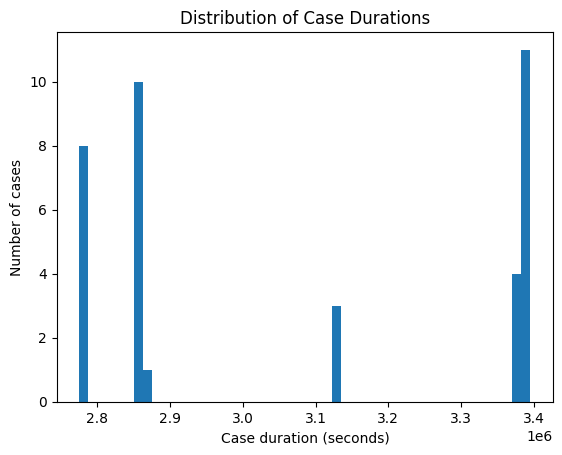

In [25]:
# Plot case duration histogram
import matplotlib.pyplot as plt

plt.hist(case_times['duration_seconds'], bins=50)
plt.xlabel("Case duration (seconds)")
plt.ylabel("Number of cases")
plt.title("Distribution of Case Durations")
plt.show()

## 10. Variants: identifying execution paths

A variant is a unique sequence of activities executed by a case.
Variants are essential for understanding process complexity and deviations.

In [26]:
# Build activity sequences per case
variants = (
    log_df_sorted
    .groupby('case:concept:name')['concept:name']
    .apply(tuple)
)

variants.head()

case:concept:name
10    (Start Shift, Open counter, Close counter, End...
13    (Start Shift, Open counter, Close counter, End...
14    (Start Shift, Open counter, Close counter, End...
15    (Start Shift, Open counter, Close counter, End...
18    (Start Shift, Open counter, Close counter, End...
Name: concept:name, dtype: object

In [27]:
# Count variant frequencies
variant_counts = variants.value_counts().reset_index()
variant_counts.columns = ['variant', 'frequency']

variant_counts.head(10)


,variant,frequency
0,"(Start Shift, Open counter, Close counter, End...",10
1,"(Start Shift, Open counter, Close counter, End...",5
2,"(Start Shift, Open counter, Close counter, End...",4
3,"(Start Shift, Open counter, Close counter, End...",4
4,"(Start Shift, Open counter, Close counter, End...",4
5,"(Start Shift, Open counter, Close counter, End...",3
6,"(Start Shift, Open counter, Close counter, End...",2
7,"(Start Shift, Open counter, Close counter, End...",2
8,"(Start Shift, Open counter, Close counter, End...",2
9,"(Start Shift, Open counter, Close counter, End...",1


## 11. Activity frequency analysis

Activity frequencies provide a first structural view of the process.

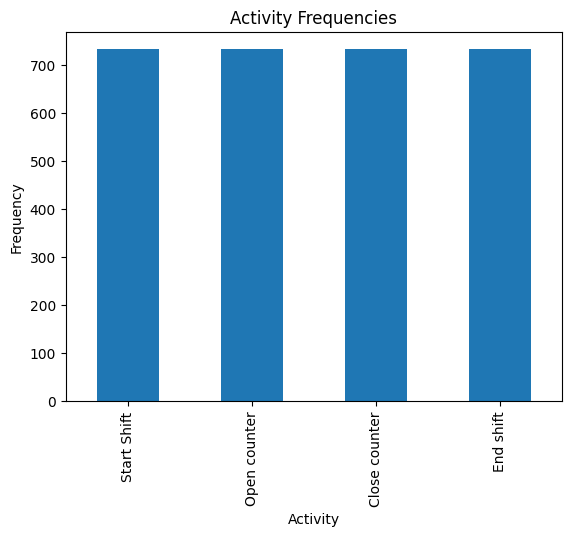

In [28]:
# Bar chart of activity frequencies
activity_counts = log_df['concept:name'].value_counts()

activity_counts.plot(kind='bar')
plt.xlabel("Activity")
plt.ylabel("Frequency")
plt.title("Activity Frequencies")
plt.show()


## 12. Temporal analysis: arrivals over time

Event logs often exhibit strong temporal patterns:

- business hours
- daily/weekly seasonality
- batching effects

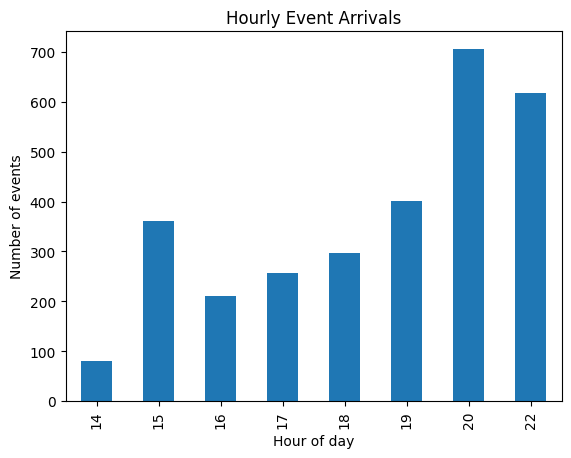

In [29]:
# Hourly arrivals
log_df['hour'] = log_df['time:timestamp'].dt.hour

hourly_arrivals = log_df.groupby('hour').size()

hourly_arrivals.plot(kind='bar')
plt.xlabel("Hour of day")
plt.ylabel("Number of events")
plt.title("Hourly Event Arrivals")
plt.show()

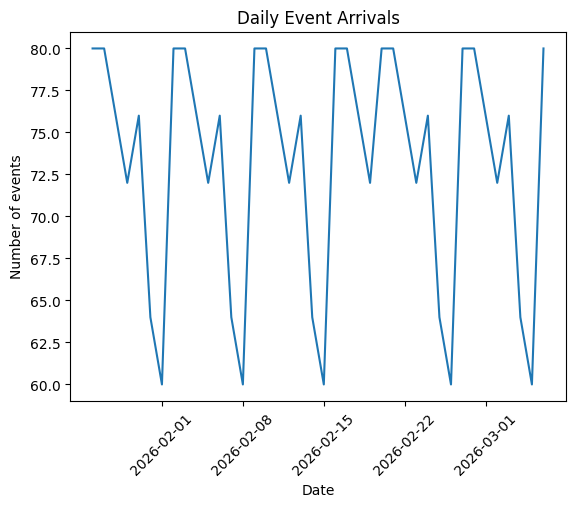

In [30]:
# Daily arrivals
log_df['date'] = log_df['time:timestamp'].dt.date

daily_arrivals = log_df.groupby('date').size()

daily_arrivals.plot()
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Number of events")
plt.title("Daily Event Arrivals")
plt.show()


## 13. Dotted chart (process timeline visualization)

A dotted chart visualizes:

- x-axis → time
- y-axis → cases
- dots → events, colored by activity

This reveals concurrency, batching, and bottlenecks.

In [31]:
import seaborn as sns

In [34]:

start = pd.Timestamp("2026-02-01 14:00:00", tz="UTC")
end   = pd.Timestamp("2026-03-16 23:59:59", tz="UTC")

log_df_day = log_df[
    (log_df['time:timestamp'] >= start) &
    (log_df['time:timestamp'] < end)
]



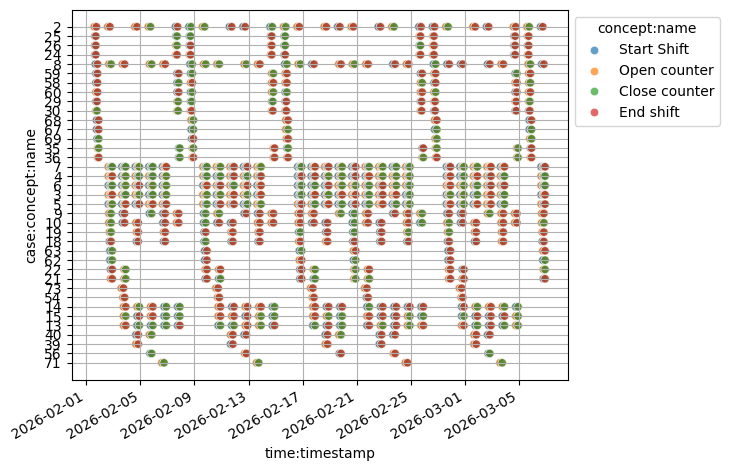

In [35]:
dotted_chart = sns.scatterplot(log_df_day.sort_values(by="time:timestamp"), x='time:timestamp', y='case:concept:name', hue='concept:name', alpha=.7)
sns.move_legend(dotted_chart, "upper left", bbox_to_anchor=(1, 1))
plt.xticks(rotation=30, ha="right")
plt.grid()
dotted_chart;

## 14. Process discovery with pm4py

**Process discovery** automatically derives a process model from event data.
We start with the **Directly-Follows Graph (DFG)** and discover a **Petri net**.

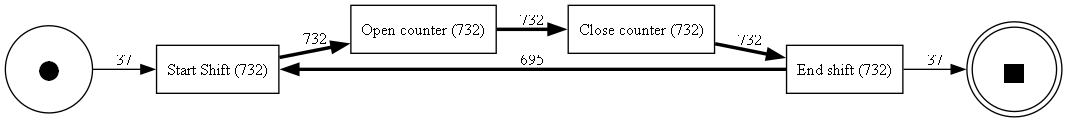

In [37]:
# Discover and visualize DFG
dfg, start_activities, end_activities = pm4py.discover_dfg(log)

pm4py.view_dfg(dfg, start_activities, end_activities)


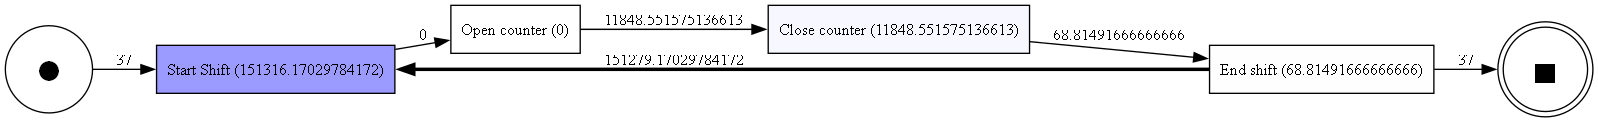

In [38]:
#Performance DFG
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery

# Discover PERFORMANCE DFG (not normal DFG)
dfg_perf = dfg_discovery.apply(log, variant=dfg_discovery.Variants.PERFORMANCE)

# Visualize it
pm4py.view_dfg(dfg_perf, start_activities, end_activities)

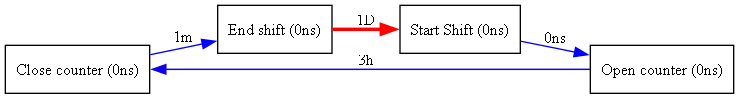

In [39]:
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_vis

# Discover performance DFG
dfg_perf = dfg_discovery.apply(log, variant=dfg_discovery.Variants.PERFORMANCE)

# Visualize in HOURS
gviz = dfg_vis.apply(
    dfg_perf,
    log=log,
    variant=dfg_vis.Variants.PERFORMANCE,
    parameters={"time_unit": "minutes"}
)

dfg_vis.view(gviz)

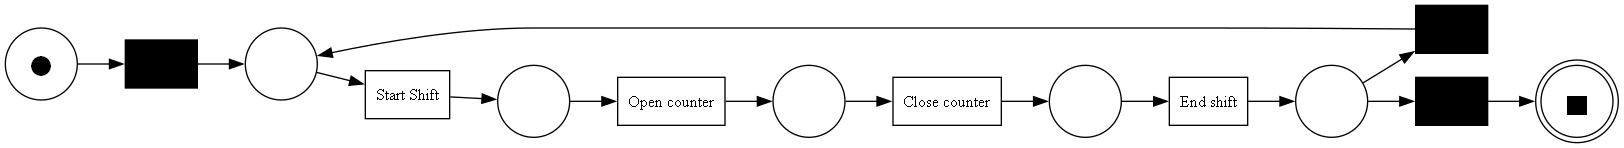

In [6]:
# Discover a Petri net (Inductive Miner)
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(log)

pm4py.view_petri_net(net, initial_marking, final_marking)


## Other things to consider when working with XES logs

- Missing or inconsistent timestamps
- Multiple events with identical timestamps
- Multiple lifecycle events (start / complete)
- Very large logs that do not fit in memory
- Assuming every case follows the same path

Always *inspect before modeling*.


## Does Handover exist?

In [ ]:

# --- Notebook 1 ---
#date is date of current event
#next_date is date of next event
df_cashier = log_df_sorted

df_cashier['next_event'] = df_cashier['concept:name'].shift(-1)
df_cashier['next_time'] = df_cashier['time:timestamp'].shift(-1)

df_cashier['date'] = df_cashier['time:timestamp'].dt.date
df_cashier['next_date'] = df_cashier['next_time'].dt.date

handover = df_cashier[
    (df_cashier['concept:name'] == 'End shift') &
    (df_cashier['next_event'] == 'Start Shift') &
    (df_cashier['date'] == df_cashier['next_date'])
].copy()

handover['gap_min'] = (
    (handover['next_time'] - handover['time:timestamp'])
    .dt.total_seconds() / 60
)

# 🔥 Save ONLY what you need
handover[['time:timestamp','next_time','gap_min']].to_csv("handover.csv", index=False)